In [16]:
##modules
#%matplotlib widget
%matplotlib inline
#
#%matplotlib qt
import mne
import numpy as np
import matplotlib
# Establecer un backend interactivo, como 'Qt5Agg', 'GTK3Agg', etc.
# Esto depende de los backends disponibles en tu sistema.

import matplotlib.pyplot as plt

#matplotlib.use('TkAgg')  # Asegúrate de que este backend está instalado.

import pandas as pd 
import os
import sys

from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs

from os.path import join as pathjoin
from time import time

from pathlib import Path

from autoreject import AutoReject

# aplicar la acf EN epochs

from statsmodels.tsa.stattools import acf


from scipy.stats import permutation_test

sys.path.append(r"G:\apuntes_mne\code_MOUS\scripts_functions_created")

# Ahora importa la función
from print5 import print5

In [17]:

 
try:
    # Si se ejecuta como SCRIPT .py: usar __file__
    sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
except NameError:
    # Si se ejecuta como NOTEBOOK Jupyter: usar path relativo
    sys.path.append("..")  # sube un nivel desde la carpeta actual del notebook


# --- Configuración dinámica de rutas ---
from get_paths_MOUS import get_paths_MOUS

# Parámetros editables
disco = "g"
modality = "visual"
layer_script = "event"
subj = "sub-V1001"
#subj = sys.argv[1] ## name of participant list


# Generar variables automáticamente
path_dict = get_paths_MOUS(disco=disco, modality=modality, layer_script=layer_script, subj=subj)
globals().update(path_dict)

# Mostrar todos los paths generados
print("\n📁 Rutas generadas:")
for k, v in path_dict.items():
    print(f"{k:<20} → {v}")




📁 Rutas generadas:
datadir              → g:\MOUS_204\MOUS_visual
general_datadir      → g:\MOUS_204
output_preproc       → g:\MOUS_204\MOUS_visual\output_preproc
mri_dir              → g:\MOUS_204\sub-V1001\anat
meg_dir              → g:\MOUS_204\sub-V1001\meg
preproc_path         → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event
channels_structure_path → g:\MOUS_204\channels_structure
epochs_path          → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\epochs_event
ICA_path             → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\ICA_event
epochs_clean_path    → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\epochs_clean_event
evoked_path          → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\evoked_event
source_path          → g:\MOUS_204\MOUS_visual\output_source\source_event
raw_hsp_path         → g:\MOUS_204\MOUS_visual\output_source\source_event\raw_hsp
fwd_path             → g:\MOUS_204\MOUS_visual\output_source\source_event\fwd
inverse_pat

In [18]:
def print5(*args):
    print(*(f"{x:.5f}" if isinstance(x, float) else x for x in args))

channels = pd.read_csv(channels_structure_path / f"channels_mag_{modality}.csv")
channels_mag=channels[channels[f"canal_efectivo_{modality}"].notna()][f"canal_efectivo_{modality}"]

channels_mag=channels_mag.tolist()
print5(channels_mag)
indice_channels_efectivos = channels[channels[f"canal_efectivo_{modality}"].notna()]["indice"]
indice_channels_efectivos=indice_channels_efectivos.tolist()
# del channels

# del channels

['MLC11-4304', 'MLC12-4304', 'MLC13-4304', 'MLC14-4304', 'MLC15-4304', 'MLC16-4304', 'MLC17-4304', 'MLC21-4304', 'MLC22-4304', 'MLC23-4304', 'MLC24-4304', 'MLC25-4304', 'MLC31-4304', 'MLC32-4304', 'MLC41-4304', 'MLC42-4304', 'MLC51-4304', 'MLC52-4304', 'MLC53-4304', 'MLC54-4304', 'MLC55-4304', 'MLC61-4304', 'MLC62-4304', 'MLC63-4304', 'MLF11-4304', 'MLF12-4304', 'MLF13-4304', 'MLF14-4304', 'MLF21-4304', 'MLF22-4304', 'MLF23-4304', 'MLF24-4304', 'MLF25-4304', 'MLF31-4304', 'MLF32-4304', 'MLF33-4304', 'MLF34-4304', 'MLF35-4304', 'MLF41-4304', 'MLF42-4304', 'MLF43-4304', 'MLF44-4304', 'MLF45-4304', 'MLF46-4304', 'MLF51-4304', 'MLF52-4304', 'MLF53-4304', 'MLF54-4304', 'MLF55-4304', 'MLF56-4304', 'MLF61-4304', 'MLF63-4304', 'MLF64-4304', 'MLF65-4304', 'MLF66-4304', 'MLF67-4304', 'MLO11-4304', 'MLO12-4304', 'MLO13-4304', 'MLO14-4304', 'MLO21-4304', 'MLO22-4304', 'MLO23-4304', 'MLO24-4304', 'MLO31-4304', 'MLO32-4304', 'MLO33-4304', 'MLO34-4304', 'MLO41-4304', 'MLO42-4304', 'MLO43-4304', 'MLO4

In [19]:
#lectura de los diccionarios ISC_zinnen y ISC_woorden
conditions = ["zinnen", "woorden"]


for cond in conditions:
    if cond == "zinnen":
        dict_zinnen = pd.read_pickle(ISC_path /f"dict_isc_window_all_{cond}_{layer_script}.pkl")
    else:
        dict_woorden = pd.read_pickle(ISC_path /f"dict_isc_window_all_{cond}_{layer_script}.pkl")

        

window_intervals = dict_zinnen["window_intervals"]

In [20]:
#this block is stupid, as I can use directly the dictionare, 
#I want the values

# for cond in conditions
#     for i in range(len(window_intervals)):
#         print(f"Intervalo {i+1}: {window_intervals[i]} segundos")
#         ##channels significative adjusted in each condition
#         numbers_channels_woorden= dict_woorden["significative_channels_adjusted_woorden"]
#         numbers_channels_zinnen= dict_zinnen["significative_channels_adjusted_zinnen"]
#         print("numbers_channels_woorden", numbers_channels_woorden, "numbers_channels_zinnen", numbers_channels_zinnen)
#         print("len(numbers_channels_woorden)=",len(numbers_channels_woorden),  "len(numbers_channels_zinnen)=",len(numbers_channels_zinnen))

#         names_channels_woorden=[channels_mag[i] for i in numbers_channels_woorden]
#         names_channels_zinnen=[channels_mag[i] for i in numbers_channels_zinnen]

#         print("names_channels_woorden", names_channels_woorden)
#         print("names_channels_zinnen", names_channels_zinnen)

#         #establecimiento de canales palabras, canales frases y canales mixtos
#         numbers_channels_only_woorden = list(
#             set(numbers_channels_woorden) - set(numbers_channels_zinnen)
#         )

#         numbers_channels_only_zinnen = list(
#             set(numbers_channels_zinnen) - set(numbers_channels_woorden)
#         )

#         number_channels_intersection = list(
#             set(numbers_channels_woorden) & set(numbers_channels_zinnen)
#         )

#         print(f"len(significative_channels_only_woorden): {len(numbers_channels_only_woorden)},\
#             len(significative_channels_only_zinnen): {len(numbers_channels_only_zinnen)},\
#             len(significative_channels_intersection) {len(number_channels_intersection)}")

#         #create list of names of channels

#         names_channels_only_woorden = [channels_mag[i] for i in numbers_channels_only_woorden]
#         names_channels_only_zinnen = [channels_mag[i] for i in numbers_channels_only_zinnen]
#         names_channels_intersection = [channels_mag[i] for i in number_channels_intersection]

In [21]:


# iscs_bootstrap_woorden=dict_woorden["iscs_bootstrap_woorden"]
# iscs_bootstrap_zinnen=dict_zinnen["iscs_bootstrap_zinnen"]

# TRW= iscs_bootstrap_zinnen - iscs_bootstrap_woorden

## PLOTS for ISCS

In [22]:
##plots for ISC

#read epochs to build evoked
#read epochs to build evoked
epochs_zinnen=mne.read_epochs(epochs_clean_path / f"{subj}_epochs_zinnen_{layer_script}-epo.fif")
len(epochs_zinnen.pick("mag", exclude="bads").ch_names)


evokeds_zinnen=epochs_zinnen.average()
## evokeds_zinnen es una lista

##cojo el primer elemento, solo tengo una lista
evoked_zinnen=evokeds_zinnen

info=evoked_zinnen.info
del epochs_zinnen
del evokeds_zinnen
del evoked_zinnen


Reading g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\epochs_clean_event\sub-V1001_epochs_zinnen_event-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    8000.00 ms
        0 CTF compensation matrices available
Not setting metadata
118 matching events found
No baseline correction applied
0 projection items activated


▶️ ZINNEN - Intervalo 1: (0.0, 3.0) segundos
▶️ ZINNEN - Intervalo 2: (0.35, 3.35) segundos
▶️ ZINNEN - Intervalo 3: (0.7, 3.7) segundos
▶️ ZINNEN - Intervalo 4: (1.05, 4.05) segundos
▶️ ZINNEN - Intervalo 5: (1.4, 4.4) segundos
▶️ ZINNEN - Intervalo 6: (1.75, 4.75) segundos
▶️ ZINNEN - Intervalo 7: (2.1, 5.1) segundos
▶️ ZINNEN - Intervalo 8: (2.45, 5.45) segundos
▶️ ZINNEN - Intervalo 9: (2.8, 5.8) segundos
▶️ ZINNEN - Intervalo 10: (3.15, 6.15) segundos
▶️ ZINNEN - Intervalo 11: (3.5, 6.5) segundos
▶️ ZINNEN - Intervalo 12: (3.85, 6.85) segundos
▶️ ZINNEN - Intervalo 13: (4.2, 7.2) segundos
▶️ ZINNEN - Intervalo 14: (4.55, 7.55) segundos
▶️ ZINNEN - Intervalo 15: (4.9, 7.9) segundos
▶️ WOORDEN - Intervalo 1: (0.0, 3.0) segundos
▶️ WOORDEN - Intervalo 2: (0.35, 3.35) segundos
▶️ WOORDEN - Intervalo 3: (0.7, 3.7) segundos
▶️ WOORDEN - Intervalo 4: (1.05, 4.05) segundos
▶️ WOORDEN - Intervalo 5: (1.4, 4.4) segundos
▶️ WOORDEN - Intervalo 6: (1.75, 4.75) segundos
▶️ WOORDEN - Intervalo 

C:\Users\UCM\AppData\Local\Temp\ipykernel_5904\2042997396.py:40: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 6))


▶️ WOORDEN - Intervalo 10: (3.15, 6.15) segundos
▶️ WOORDEN - Intervalo 11: (3.5, 6.5) segundos
▶️ WOORDEN - Intervalo 12: (3.85, 6.85) segundos
▶️ WOORDEN - Intervalo 13: (4.2, 7.2) segundos
▶️ WOORDEN - Intervalo 14: (4.55, 7.55) segundos
▶️ WOORDEN - Intervalo 15: (4.9, 7.9) segundos


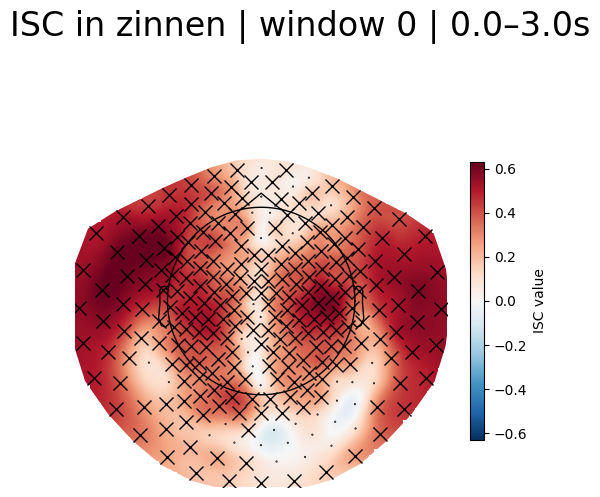

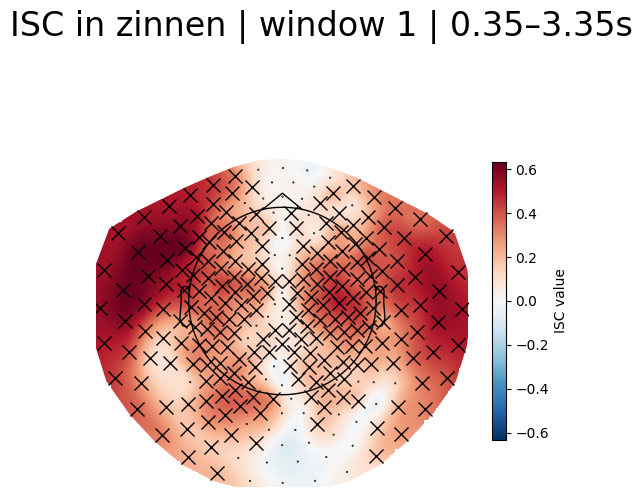

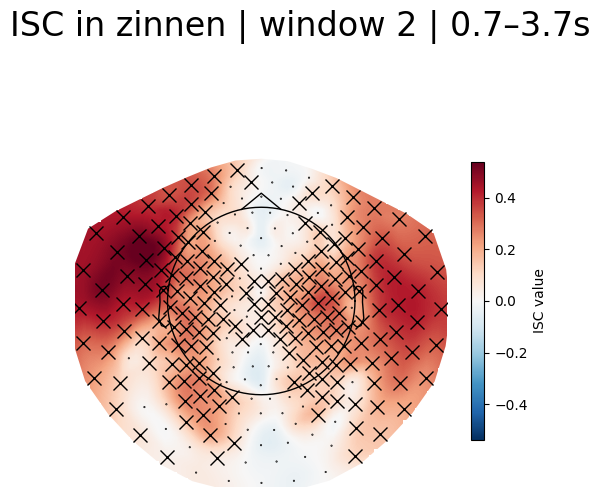

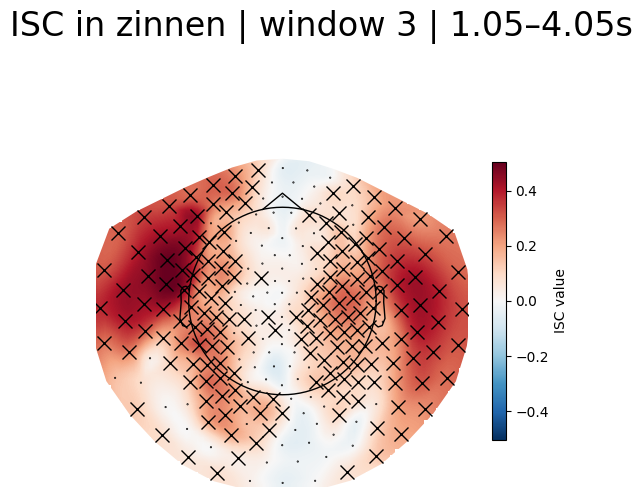

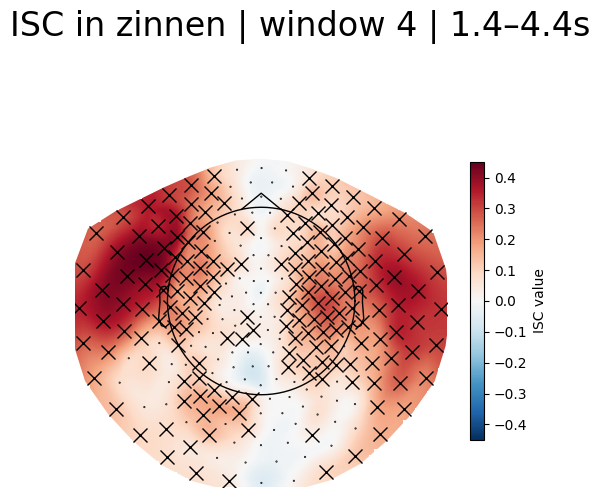

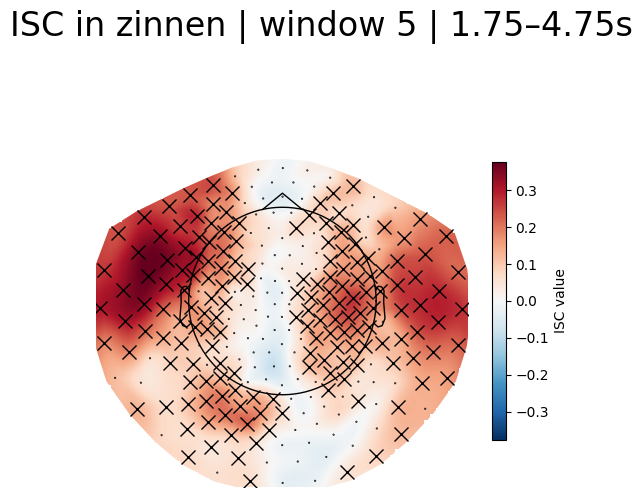

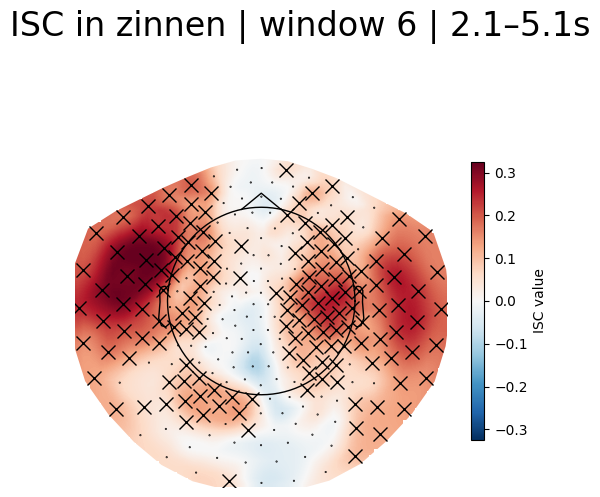

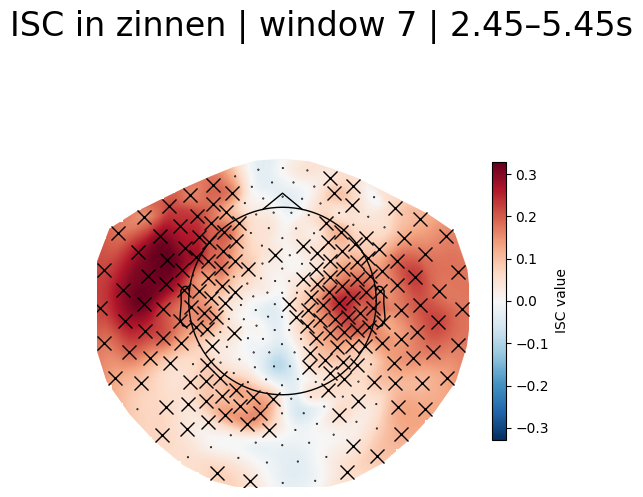

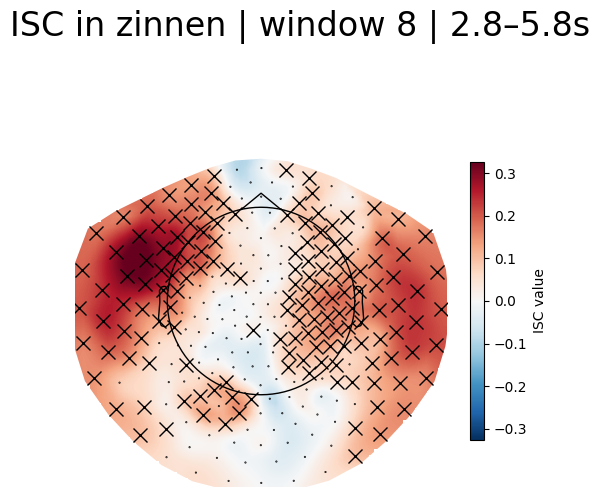

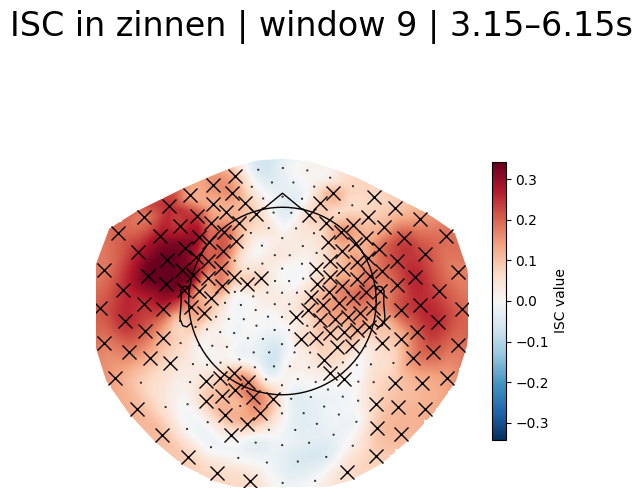

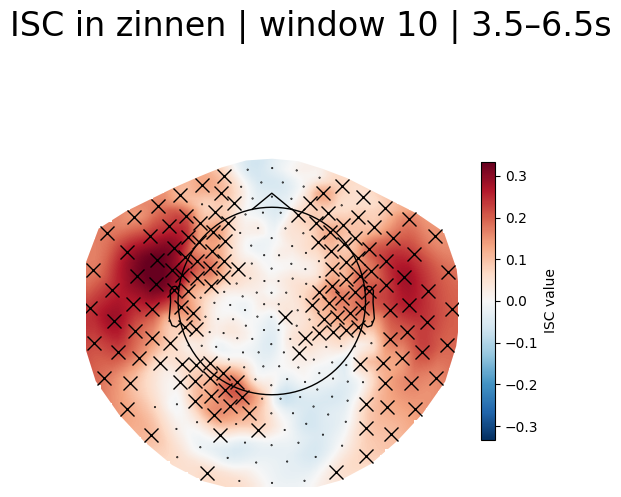

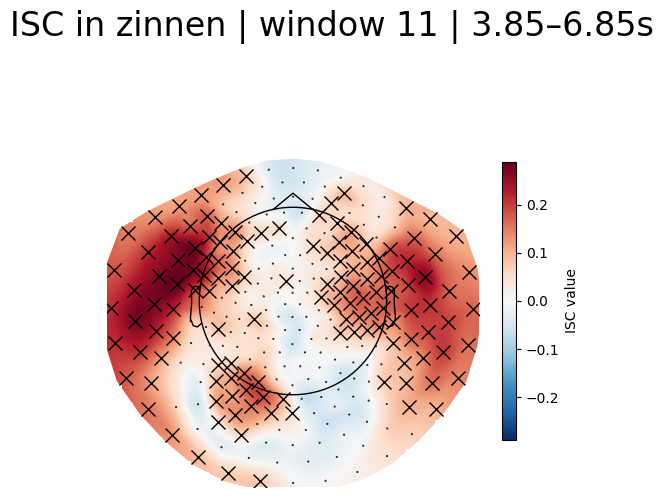

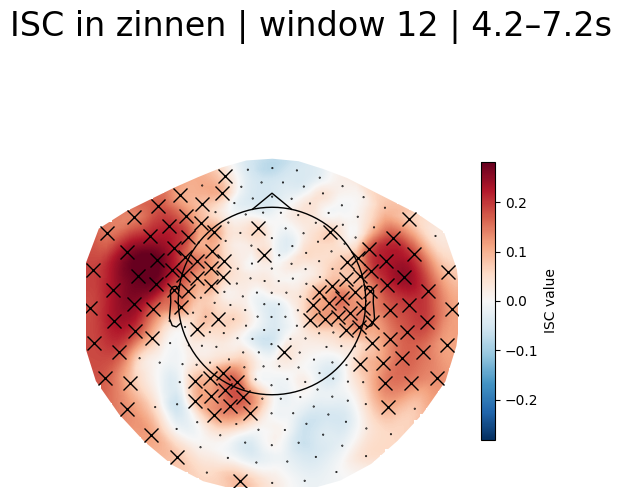

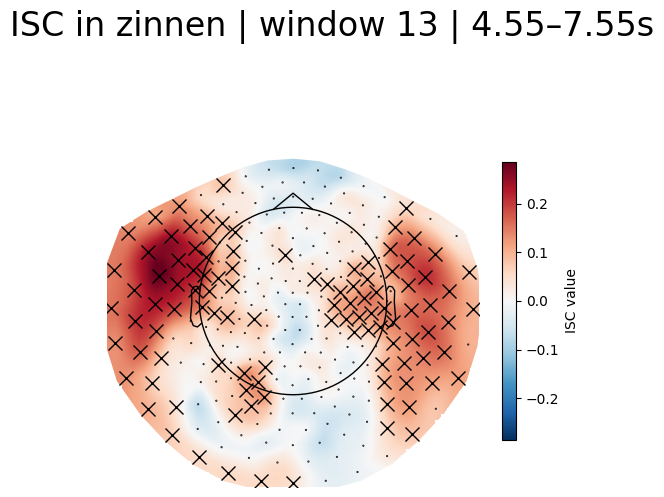

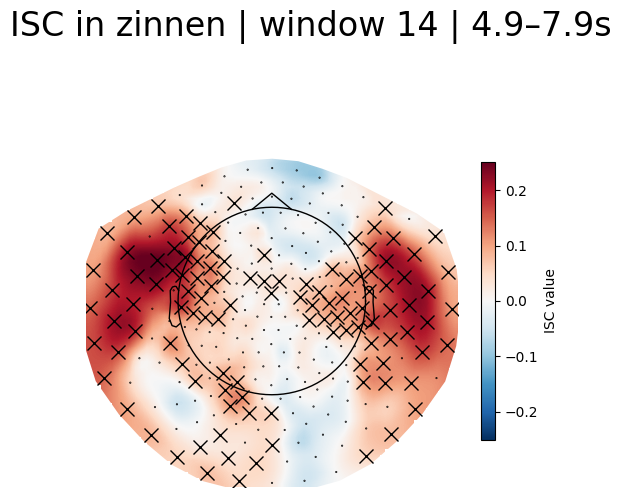

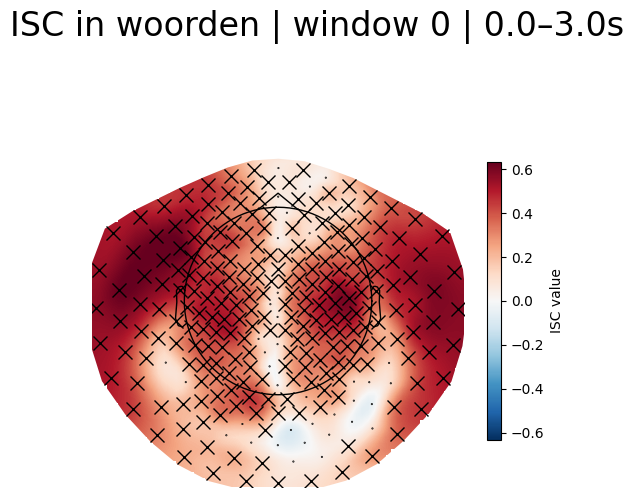

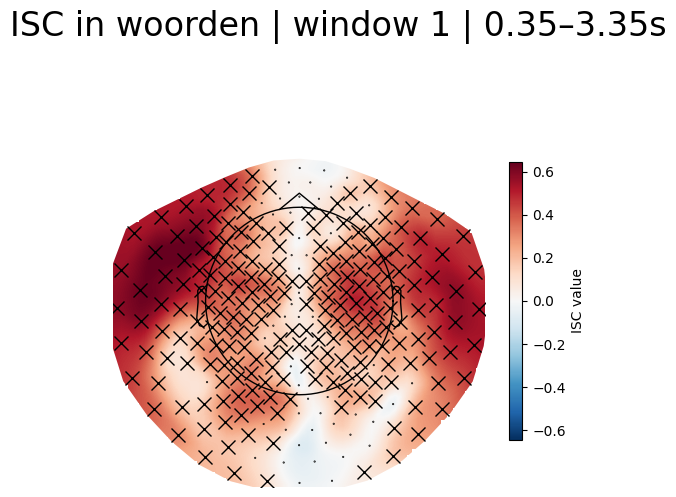

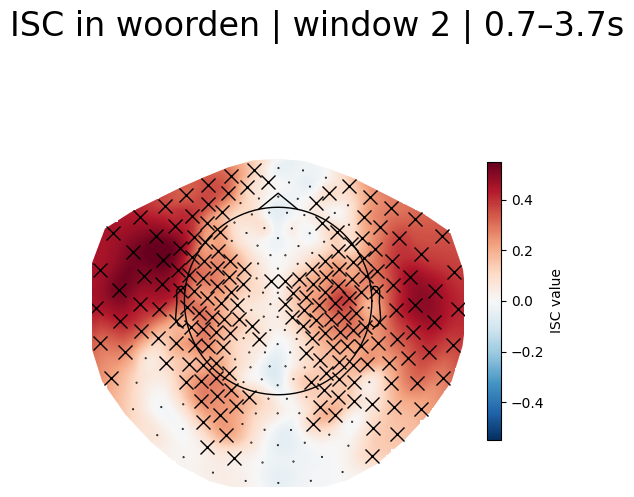

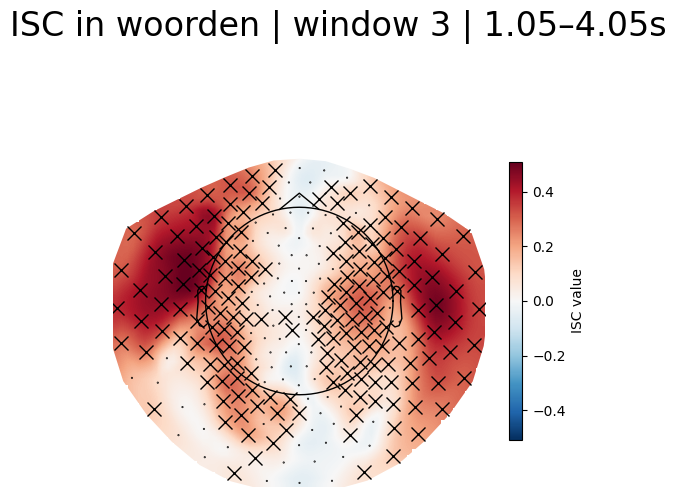

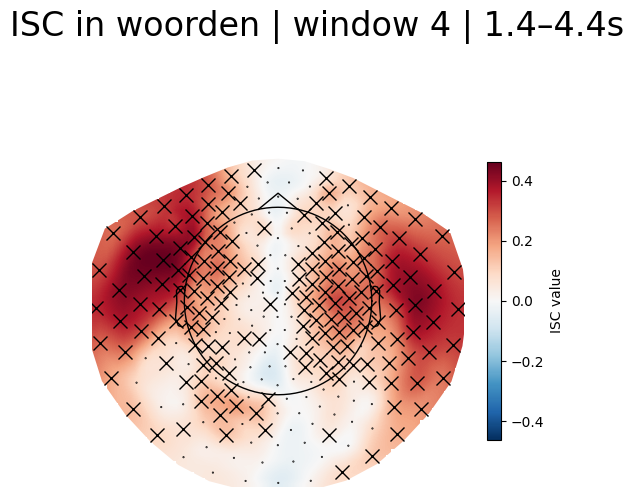

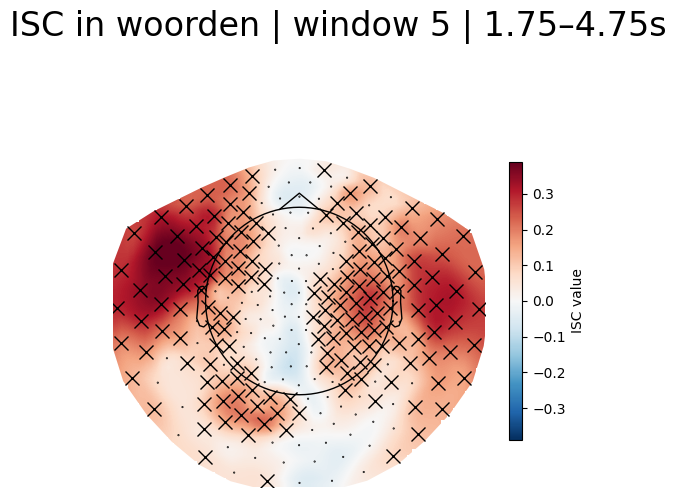

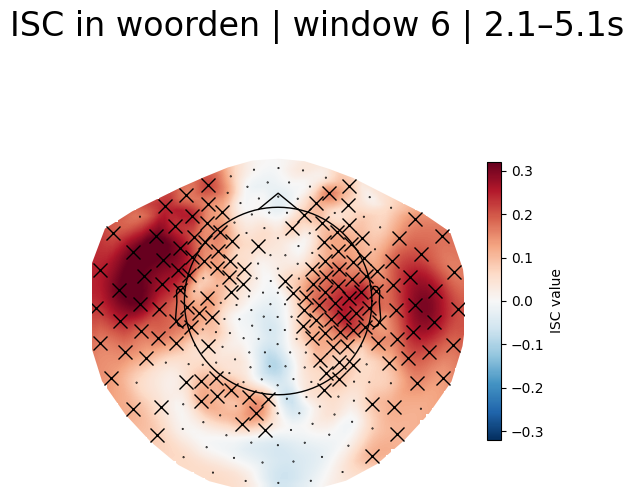

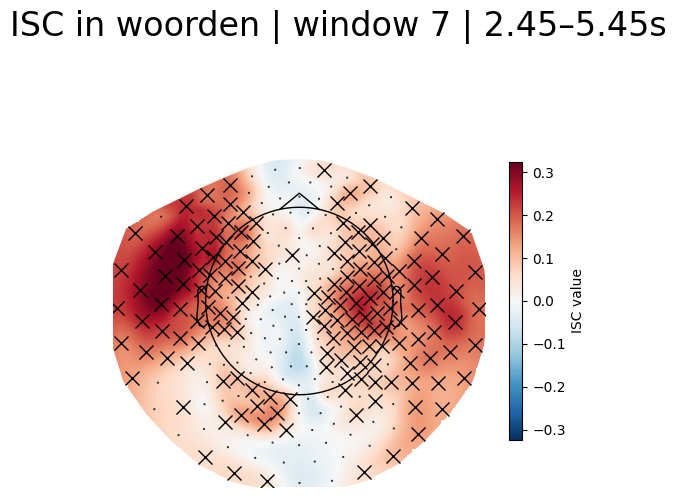

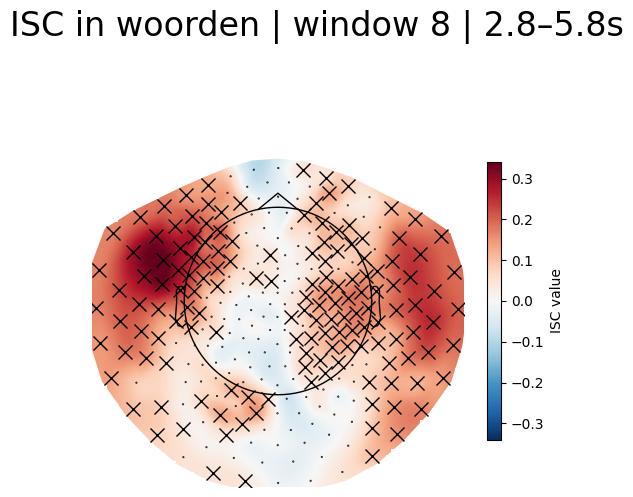

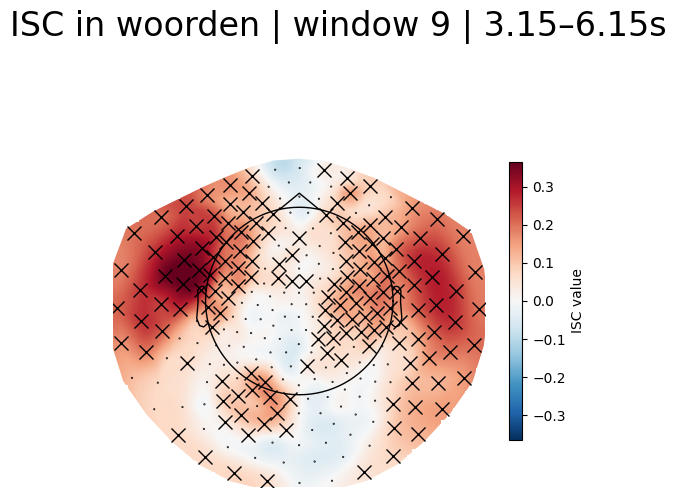

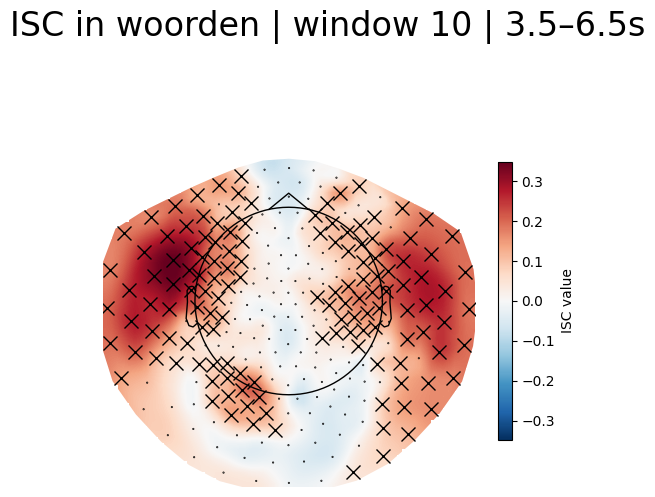

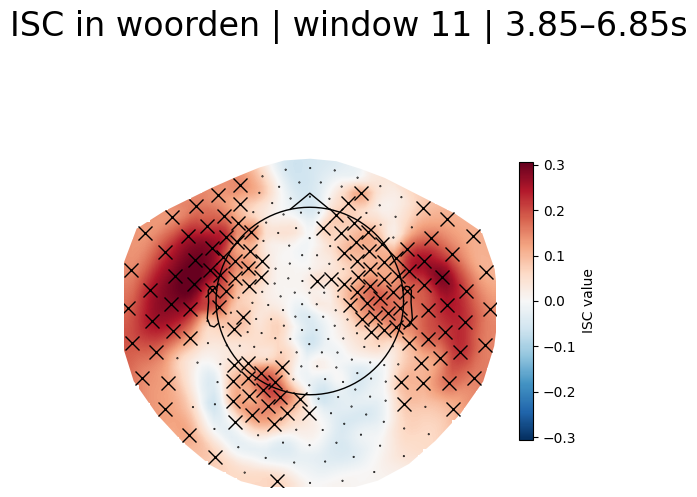

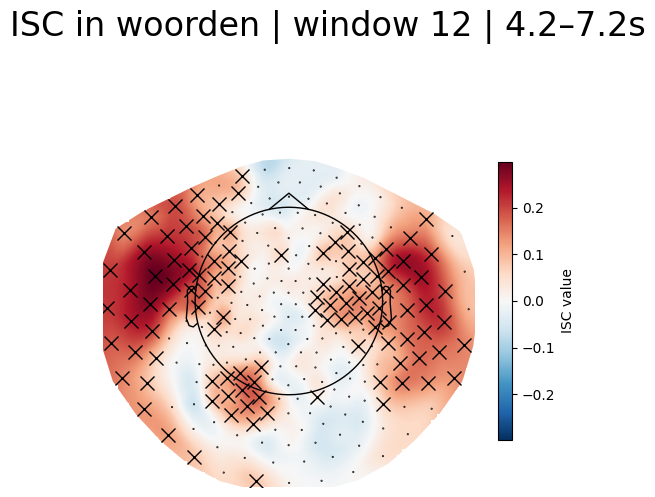

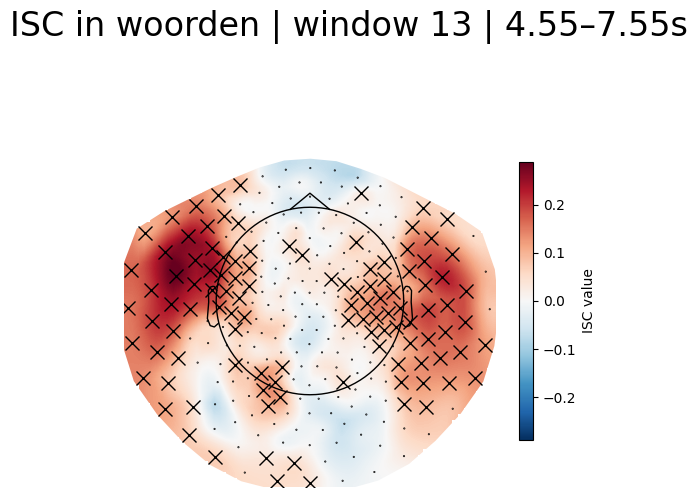

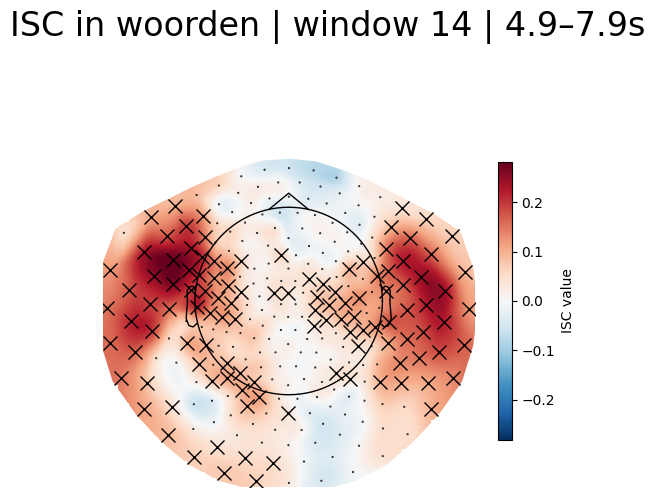

In [23]:
shape_matrix = dict_zinnen["iscs_bootstrap_window_all"][0].shape

# Loop por condición (zinnen, luego woorden)
for cond in ["zinnen", "woorden"]:
    dict_data = dict_zinnen if cond == "zinnen" else dict_woorden

    for i in range(len(window_intervals)):
        print(f"▶️ {cond.upper()} - Intervalo {i+1}: {window_intervals[i]} segundos")

        # Crear máscaras solo una vez por condición y ventana
        mask_zinnen = np.zeros(shape_matrix, dtype=bool)
        for electrode in dict_zinnen["significative_channels_adjusted_all"][i]:
            mask_zinnen[electrode] = True

        mask_woorden = np.zeros(shape_matrix, dtype=bool)
        for electrode in dict_woorden["significative_channels_adjusted_all"][i]:
            mask_woorden[electrode] = True

        mask_zinnen_only = np.zeros(shape_matrix, dtype=bool)
        for electrode in set(dict_zinnen["significative_channels_adjusted_all"][i]) - set(dict_woorden["significative_channels_adjusted_all"][i]):
            mask_zinnen_only[electrode] = True

        mask_woorden_only = np.zeros(shape_matrix, dtype=bool)
        for electrode in set(dict_woorden["significative_channels_adjusted_all"][i]) - set(dict_zinnen["significative_channels_adjusted_all"][i]):
            mask_woorden_only[electrode] = True

        mask_intersection = np.zeros(shape_matrix, dtype=bool)
        for electrode in set(dict_zinnen["significative_channels_adjusted_all"][i]) & set(dict_woorden["significative_channels_adjusted_all"][i]):
            mask_intersection[electrode] = True

        # Selección de máscara según condición
        if cond == "zinnen":
            mask = mask_zinnen
        elif cond == "woorden":
            mask = mask_woorden

        values = dict_data["iscs_bootstrap_window_all"][i]

        # Crear figura
        fig, ax = plt.subplots(figsize=(6, 6))
        im, _ = mne.viz.plot_topomap(
            data=values,
            pos=info,
            mask=mask,
            axes=ax,
            cmap='RdBu_r',
            vlim=(-np.max(np.abs(values)), np.max(np.abs(values))),
            mask_params={"marker": "x", "markerfacecolor": "green", "markersize": 10},
            contours=0,
            show=False
        )

        fig.suptitle(
            f"ISC in {cond} | window {i} | {window_intervals[i][0]}–{window_intervals[i][1]}s",
            fontsize=24
        )
        cbar = fig.colorbar(im, ax=ax, shrink=0.6)
        cbar.set_label("ISC value")

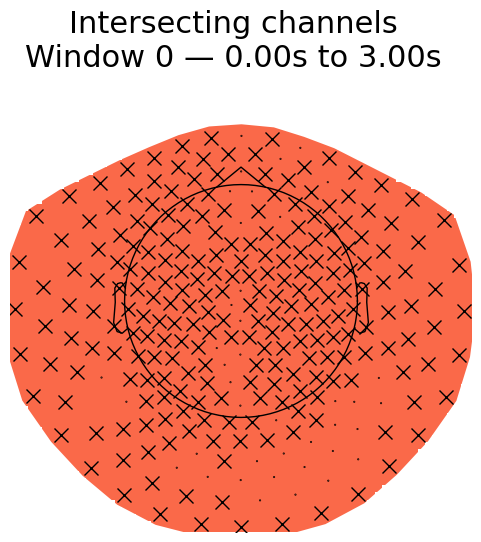

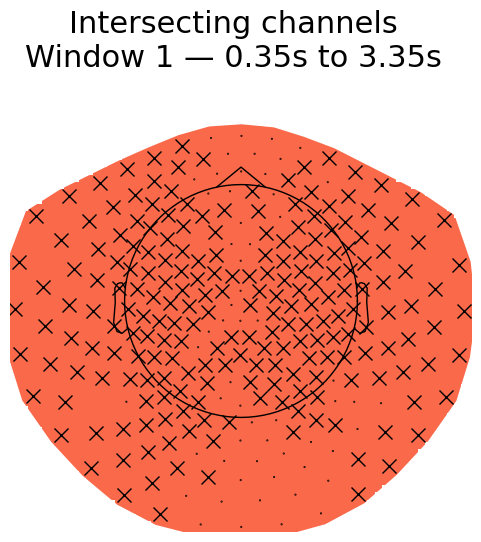

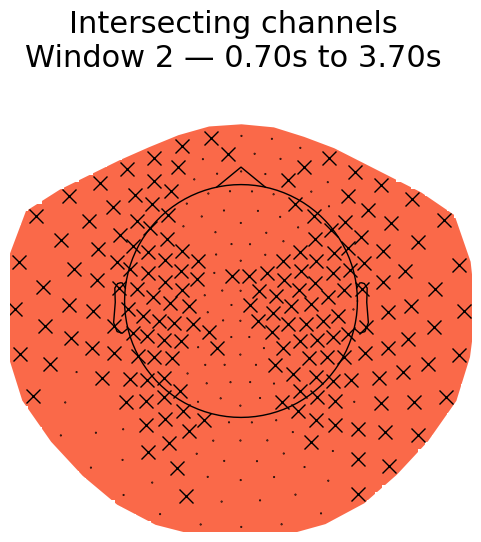

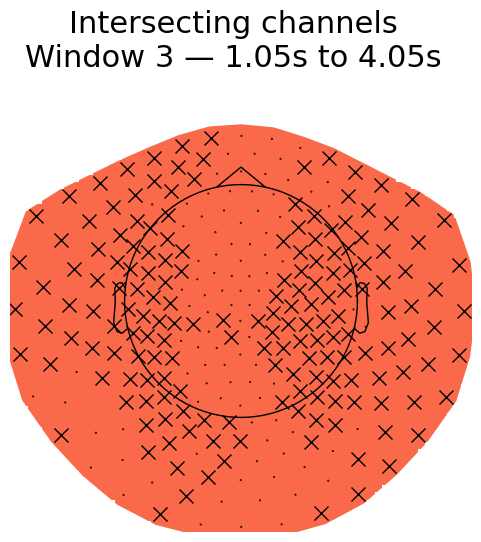

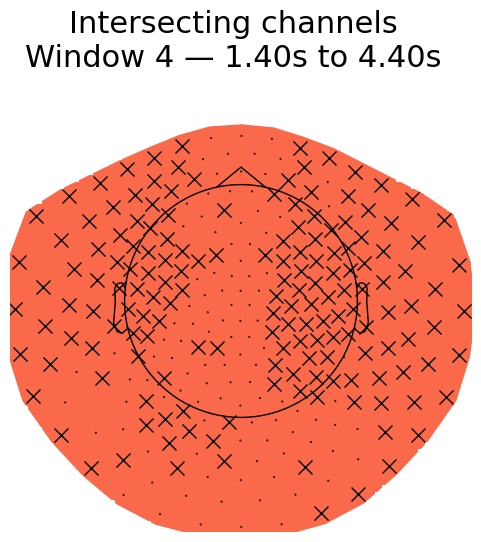

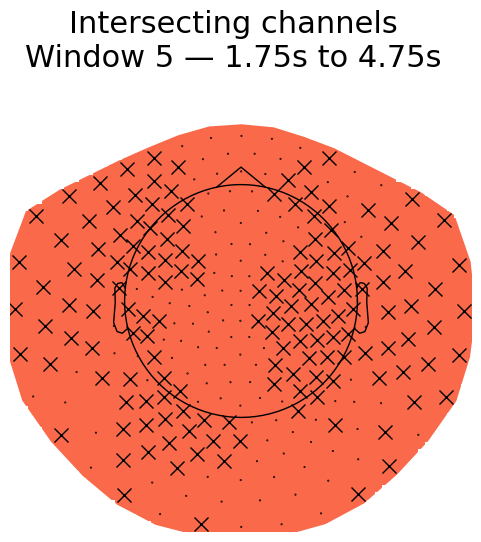

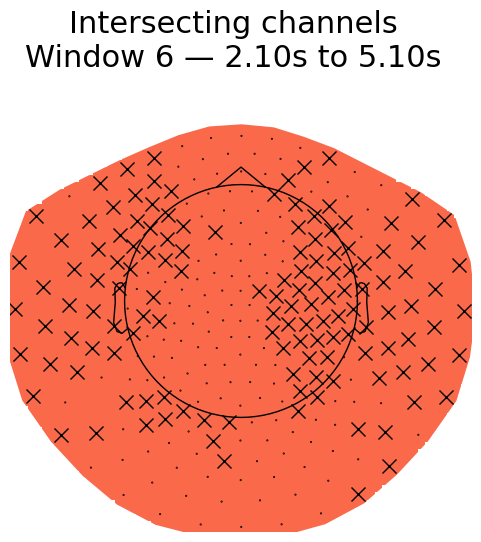

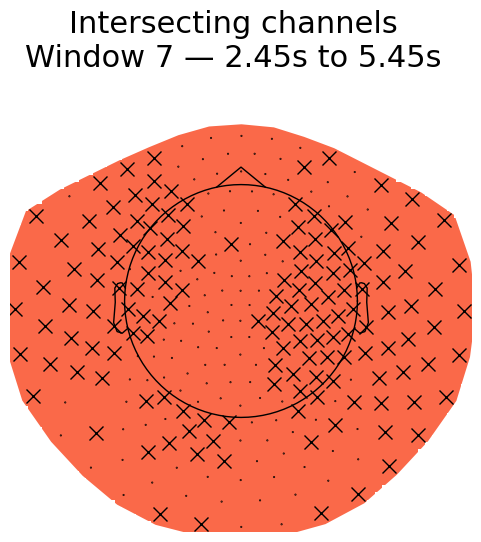

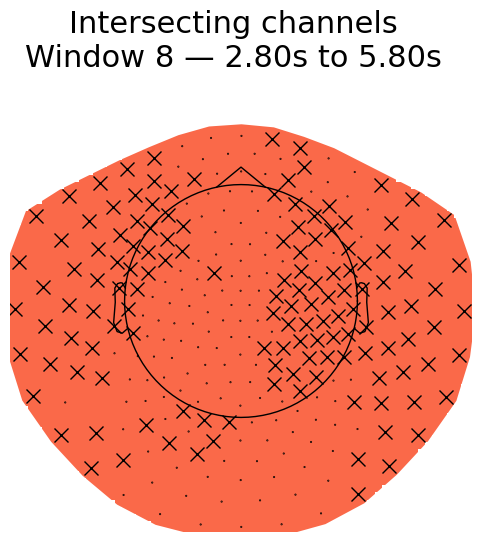

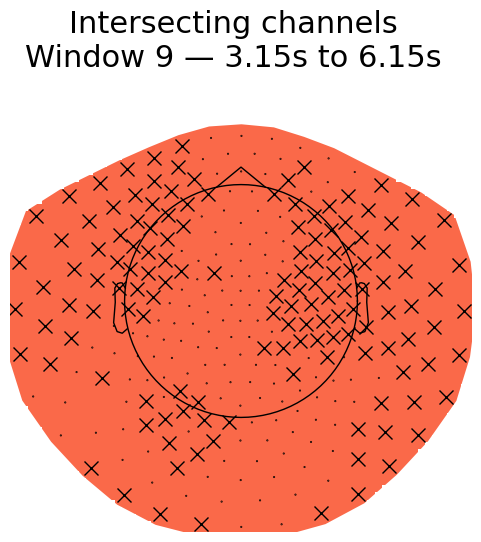

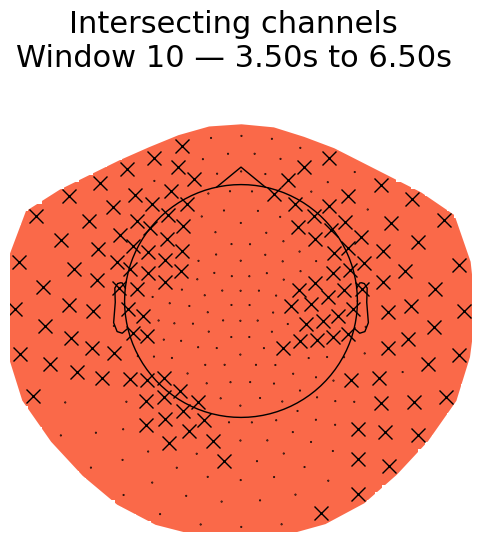

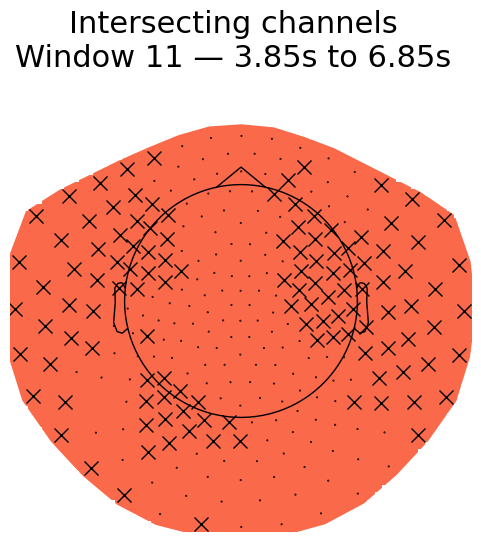

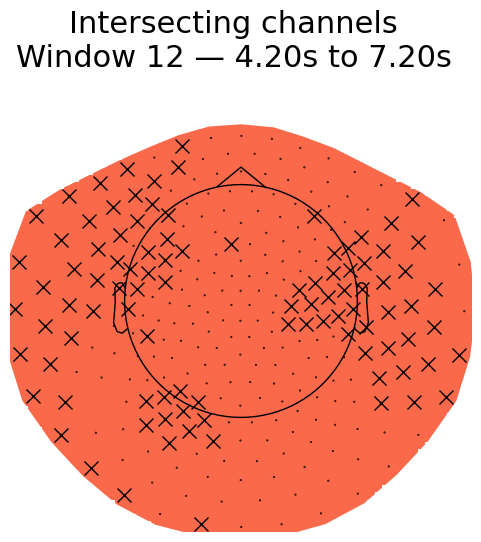

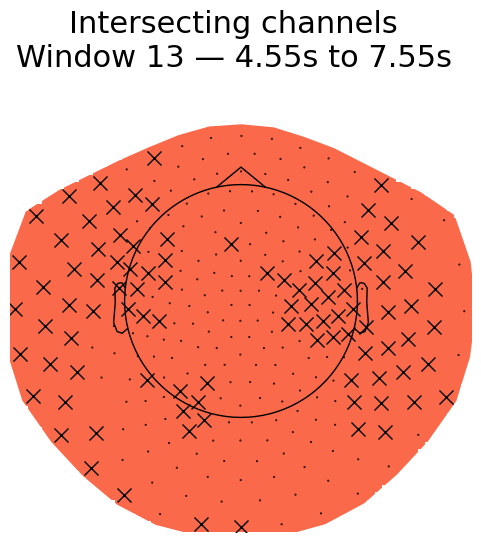

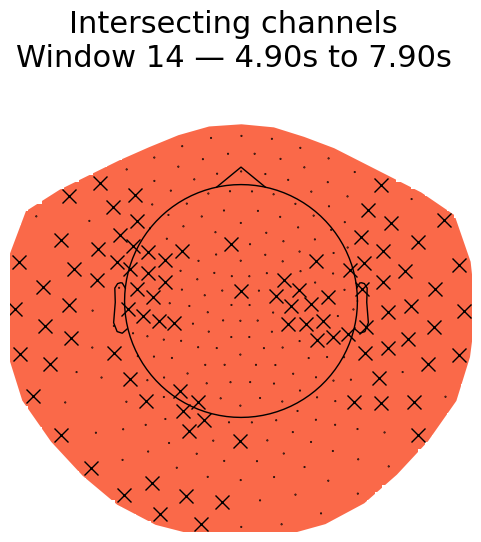

In [24]:
for i in range(len(window_intervals)):
    mask = np.zeros(shape_matrix, dtype=bool)
    for electrode in (set(dict_zinnen["significative_channels_adjusted_all"][i]) & 
                      set(dict_woorden["significative_channels_adjusted_all"][i])):
        mask[electrode] = True

    # Creamos figura y eje
    fig, ax = plt.subplots(figsize=(6, 6))

    # Creamos un array de ceros solo para marcar canales
    dummy_data = np.zeros(shape_matrix)

    im, _ = mne.viz.plot_topomap(
        data=dummy_data,
        pos=info,
        mask=mask,
        axes=ax,
        cmap='Reds',  # Puede ser cualquier color, porque los datos son 0
        vlim=(-1, 1),
        mask_params={"marker": "x", "markerfacecolor": "green", "markersize": 10},
        contours=0,
        show=False
    )

    # Título informativo
    fig.suptitle(
        f"Intersecting channels\nWindow {i} — {window_intervals[i][0]:.2f}s to {window_intervals[i][1]:.2f}s",
        fontsize=22
    )

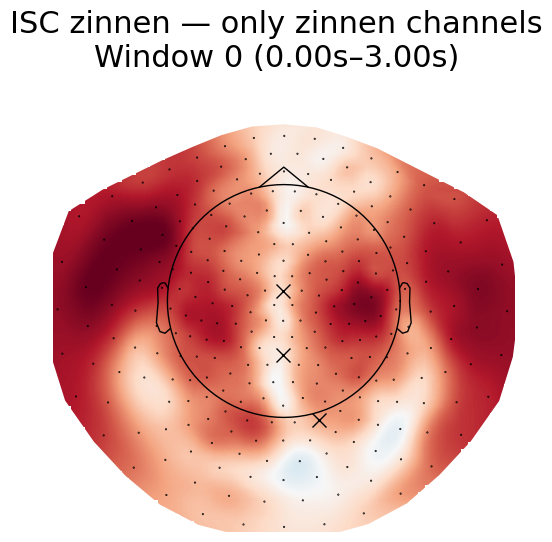

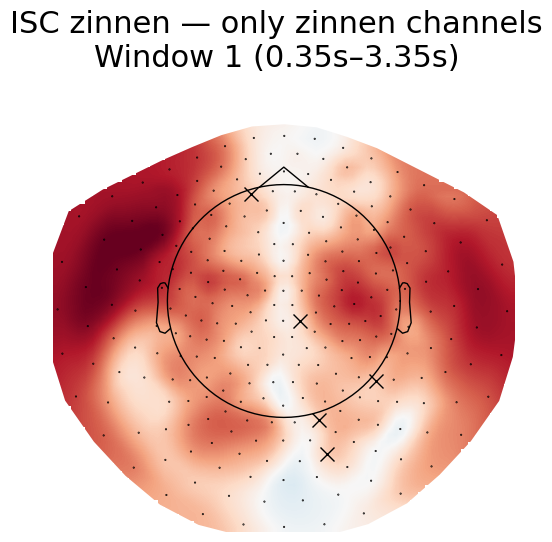

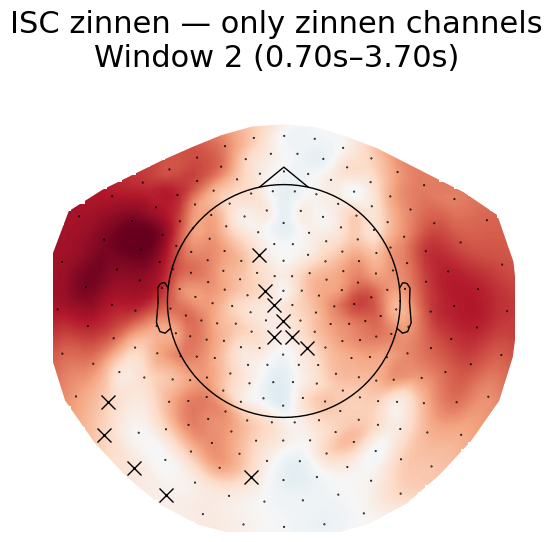

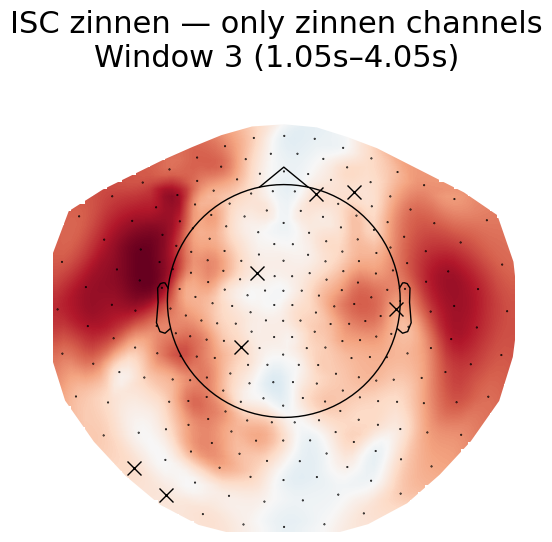

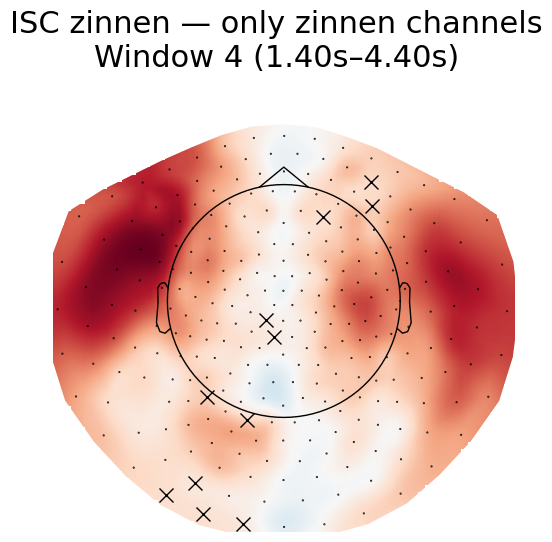

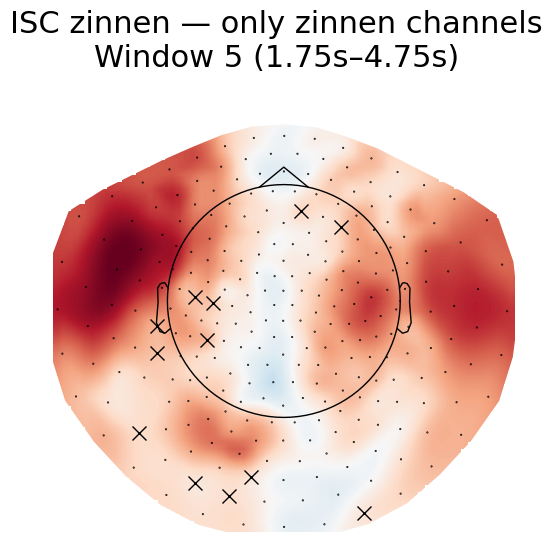

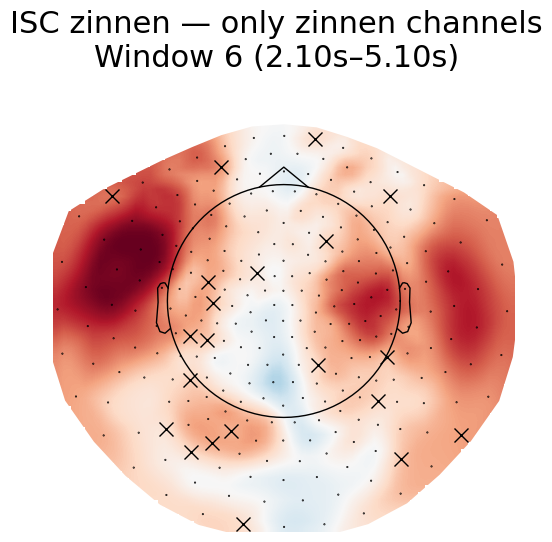

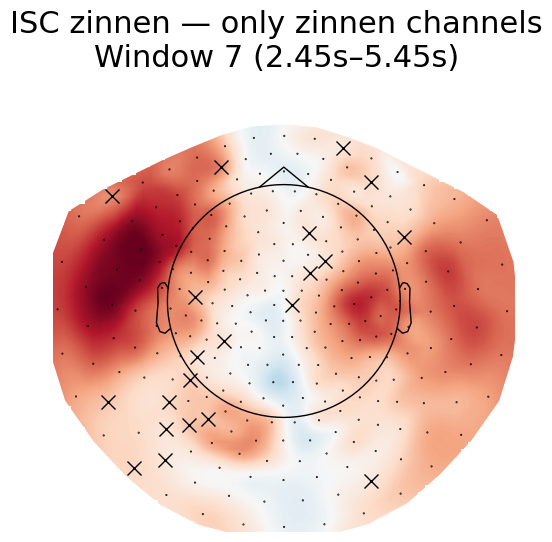

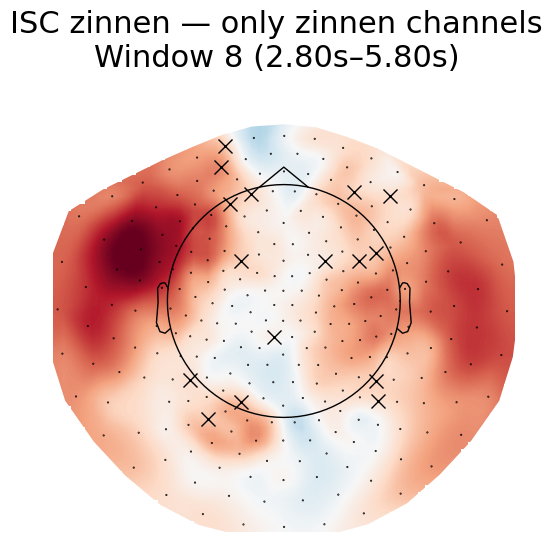

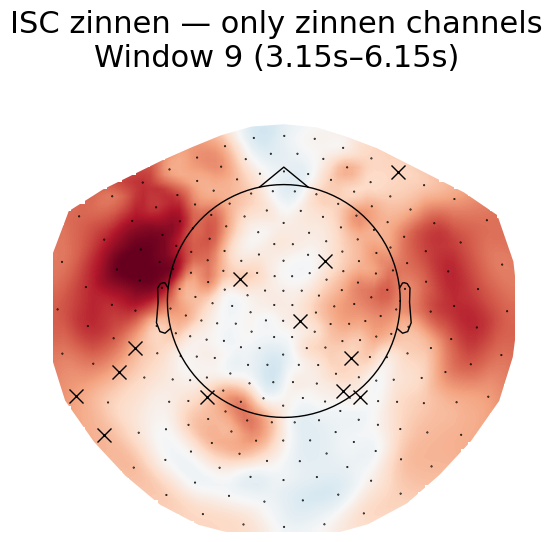

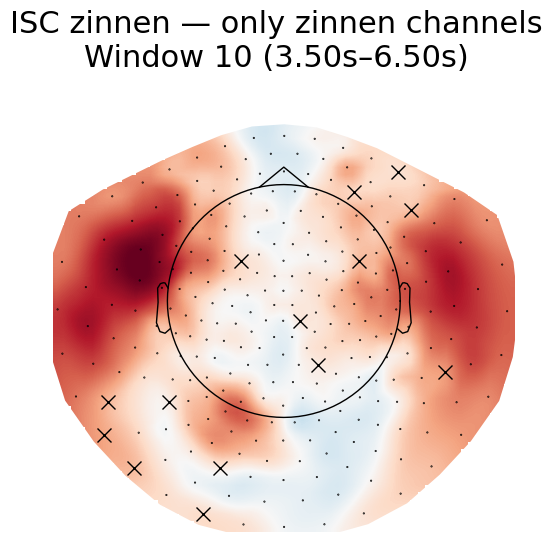

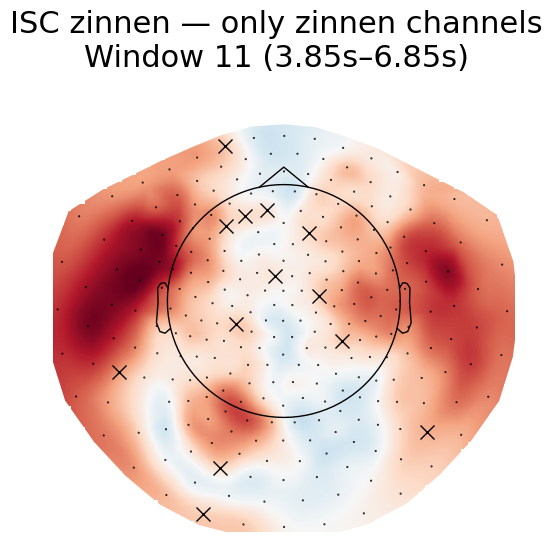

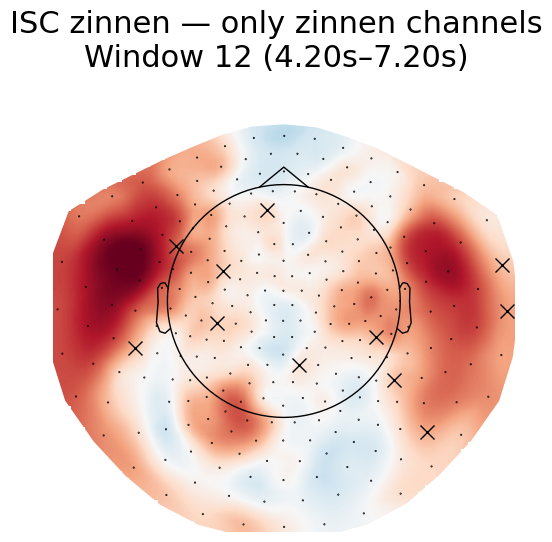

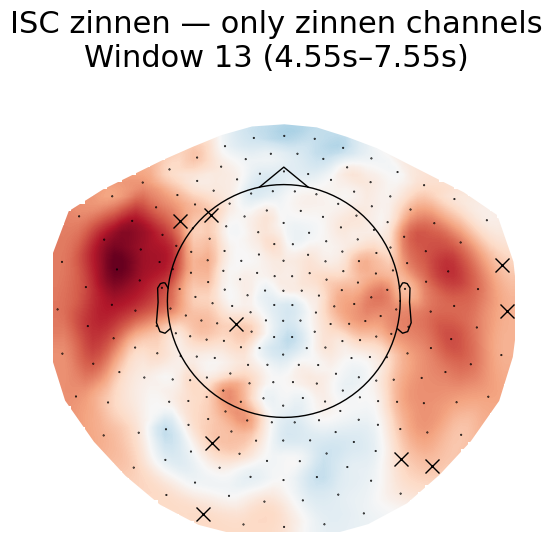

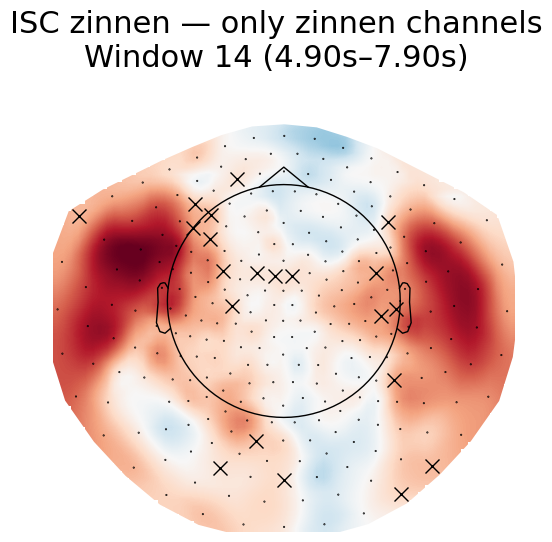

In [25]:
for i in range(len(window_intervals)):
    mask = np.zeros(shape_matrix, dtype=bool)
    for electrode in (set(dict_zinnen["significative_channels_adjusted_all"][i]) -
                      set(dict_woorden["significative_channels_adjusted_all"][i])):
        mask[electrode] = True

    values = dict_zinnen["iscs_bootstrap_window_all"][i]

    # Crear figura y eje
    fig, ax = plt.subplots(figsize=(6, 6))

    im, _ = mne.viz.plot_topomap(
        data=values,
        pos=info,
        mask=mask,
        axes=ax,
        cmap='RdBu_r',
        vlim=(-np.max(np.abs(values)), np.max(np.abs(values))),
        mask_params=dict(marker='x', markerfacecolor='green', markersize=10),
        contours=0,
        show=False
    )

    # Título informativo
    fig.suptitle(
        f"ISC zinnen — only zinnen channels\nWindow {i} ({window_intervals[i][0]:.2f}s–{window_intervals[i][1]:.2f}s)",
        fontsize=22
    )

## Posibles comparaciones estadísticas
len(significative_channels_only_woorden): 25, len(significative_channels_only_zinnen): 92, len(significative_channels_intersection) 88

Primer problema, el numero de canales zinnen es claramente superior al de woorden, big problem, aunque la interseccion es alta, tal como esperaríamos. Seguramente esto sea porque hay ruido 

- comparación ACW-50 en zinnen entre estos canales zinnen y canales woorden  + comapracion en woorden de lo mismo

- comparación entre solo zinnen con intersection  en woorden y en zinnen (aunque ojo, esto es básicamente aceptar que los canales solo Zinnen son ruido)

- comapración en el promedio general de acw en ambas condiciones de los canalaes zinnen vs promedio general de canales woorden

- comparación de la intersección vs canales no signficativos: no sé muy bien como interpretar esto

- 

## general comparisons of ISC

In [26]:


##dependent condition
def paired_statistic(diff, _):
    return np.mean(diff)

print("Differences in ISC between zinnen and woorden for each window:")
for i in range(len(window_intervals)):

    x= dict_zinnen["iscs_bootstrap_window_all"][i]
    ##notice that in this comparison y is  ch_woorden_mean or ch_intersection_mean
    y=  dict_woorden["iscs_bootstrap_window_all"][i]

    diff=x-y
    # Permutation test
    res = permutation_test(
        (diff, np.zeros_like(diff)),
        #
        statistic=paired_statistic,
        vectorized=False,
        n_resamples=10000,
        alternative='Greater', 
        random_state=42
    )
    print(f"Results for window {i+1} ({window_intervals[i][0]}-{window_intervals[i][1]}s):")
    print(f"Statistic value: {res.statistic:.6f}")
    print(f"p-value: {res.pvalue:.6f}")

Differences in ISC between zinnen and woorden for each window:
Results for window 1 (0.0-3.0s):
Statistic value: -0.004386
p-value: 1.000000
Results for window 2 (0.35-3.35s):
Statistic value: -0.003241
p-value: 1.000000
Results for window 3 (0.7-3.7s):
Statistic value: -0.003470
p-value: 1.000000
Results for window 4 (1.05-4.05s):
Statistic value: -0.005583
p-value: 1.000000
Results for window 5 (1.4-4.4s):
Statistic value: -0.004553
p-value: 1.000000
Results for window 6 (1.75-4.75s):
Statistic value: -0.001668
p-value: 0.971003
Results for window 7 (2.1-5.1s):
Statistic value: -0.001200
p-value: 0.918508
Results for window 8 (2.45-5.45s):
Statistic value: -0.000098
p-value: 0.541046
Results for window 9 (2.8-5.8s):
Statistic value: -0.001226
p-value: 0.922508
Results for window 10 (3.15-6.15s):
Statistic value: -0.003779
p-value: 1.000000
Results for window 11 (3.5-6.5s):
Statistic value: -0.003091
p-value: 0.999600
Results for window 12 (3.85-6.85s):
Statistic value: -0.002376
p-va